c:\Users\admin\Personal use\Навчання\10 семестр\Анастасійка\ШІ Лінгвістика\labs\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Успішно завантажено 9522 рядків.
Доступні колонки: ['text_v2', 'lemma_text', 'pos_seq']
Silhouette Score (Raw Text - text_v2): 0.0096
Silhouette Score (Lemmatized - lemma_text): 0.0071
Silhouette Score (POS Filtered): 0.0085


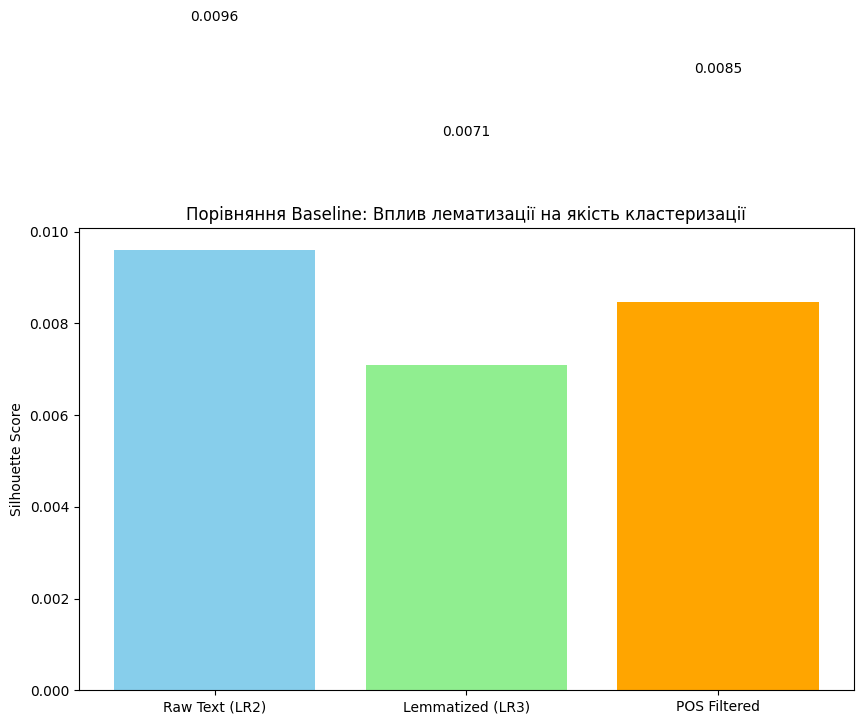

2026-03-02 20:25:55 WARNING: Language uk package default expects mwt, which has been added



--- ТЕСТУВАННЯ ЛЕМАТИЗАТОРА (EDGE CASES) ---


2026-03-02 20:25:56 INFO: Loading these models for language: uk (Ukrainian):
| Processor | Package     |
---------------------------
| tokenize  | iu          |
| mwt       | iu          |
| pos       | iu_charlm   |
| lemma     | iu_nocharlm |

2026-03-02 20:25:56 INFO: Using device: cpu
2026-03-02 20:25:56 INFO: Loading: tokenize
2026-03-02 20:25:59 INFO: Loading: mwt
2026-03-02 20:25:59 INFO: Loading: pos
2026-03-02 20:26:01 INFO: Loading: lemma
2026-03-02 20:26:01 INFO: Done loading processors!


Input           | Expected        | Actual          | Status
-----------------------------------------------------------------
громадою        | громада         | громада         | ✅
працюємо        | працювати       | працювати       | ✅
відеореєстратора | відеореєстратор | відеореєстратор | ✅
найкращий       | хороший         | найкращий       | ❌
стані           | стан            | стан            | ✅
мати            | мати            | мати            | ✅
замок           | замок           | замка           | ❌
смартфону       | смартфон        | смартфон        | ✅
відремонтовані  | відремонтувати  | відремонтований | ❌
швидко          | швидко          | швидко          | ✅
п'ять           | п'ять           | п’ять           | ❌
Києва           | Київ            | київ            | ✅
задоволений     | задоволений     | задоволений     | ✅
немає           | немає           | немати          | ❌
USB-порти       | usb-порт        | usb             | ❌
під'їзді        | під'їзд       

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import stanza
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

try:
    df = pd.read_csv('../data/processed_v3.csv', sep=';')
    print(f"Успішно завантажено {len(df)} рядків.")
    print(f"Доступні колонки: {df.columns.tolist()}")
except Exception as e:
    print(f"Помилка завантаження: {e}. Спочатку запустіть ling_features.py")

def evaluate_clustering(texts, n_clusters=5):
    """
    Векторизує тексти через TF-IDF та проводить кластеризацію KMeans.
    Повертає Silhouette Score.
    """
    clean_texts = texts.fillna('')
    
    vectorizer = TfidfVectorizer(max_features=2000, min_df=2)
    X = vectorizer.fit_transform(clean_texts)
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    return score

score_raw = evaluate_clustering(df['text_v2'])
print(f"Silhouette Score (Raw Text - text_v2): {score_raw:.4f}")

score_lemma = evaluate_clustering(df['lemma_text'])
print(f"Silhouette Score (Lemmatized - lemma_text): {score_lemma:.4f}")

def filter_by_pos(row):
    words = str(row['lemma_text']).split()
    pos_tags = str(row['pos_seq']).split()
    filtered = [w for w, p in zip(words, pos_tags) if p in ['NOUN', 'VERB', 'PROPN']]
    return " ".join(filtered)

df['filtered_pos_text'] = df.apply(filter_by_pos, axis=1)
score_pos = evaluate_clustering(df['filtered_pos_text'])
print(f"Silhouette Score (POS Filtered): {score_pos:.4f}")

results = {
    'Raw Text (LR2)': score_raw,
    'Lemmatized (LR3)': score_lemma,
    'POS Filtered': score_pos
}

plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=['skyblue', 'lightgreen', 'orange'])
plt.ylabel('Silhouette Score')
plt.title('Порівняння Baseline: Вплив лематизації на якість кластеризації')
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.show()

print("\n--- ТЕСТУВАННЯ ЛЕМАТИЗАТОРА (EDGE CASES) ---")
nlp = stanza.Pipeline(lang='uk', processors='tokenize,pos,lemma', use_gpu=False, download_method='reuse_resources')

try:
    with open('../tests/ling_edge_cases.jsonl', 'r', encoding='utf-8') as f:
        cases = [json.loads(line) for line in f]

    print(f"{'Input':<15} | {'Expected':<15} | {'Actual':<15} | {'Status'}")
    print("-" * 65)

    for case in cases:
        doc = nlp(case['input'])
        actual_lemma = doc.sentences[0].words[0].lemma.lower()
        status = "✅" if actual_lemma == case['expected_lemma'].lower() else "❌"
        print(f"{case['input']:<15} | {case['expected_lemma']:<15} | {actual_lemma:<15} | {status}")
except FileNotFoundError:
    print("Файл tests/ling_edge_cases.jsonl не знайдено.")